![](./images/mpl_logo.png)

# Twin Axes

Dalam sesi ini kita akan mempelajari twin axes pada Matplotlib.

## Import modules

In [1]:
%matplotlib inline

In [2]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

print(matplotlib.__version__)
print(np.__version__)

3.9.2
1.26.4


## Kasus Twin Axes 1

In [3]:
x = np.linspace(1, 10, 25)
x

array([ 1.   ,  1.375,  1.75 ,  2.125,  2.5  ,  2.875,  3.25 ,  3.625,
        4.   ,  4.375,  4.75 ,  5.125,  5.5  ,  5.875,  6.25 ,  6.625,
        7.   ,  7.375,  7.75 ,  8.125,  8.5  ,  8.875,  9.25 ,  9.625,
       10.   ])

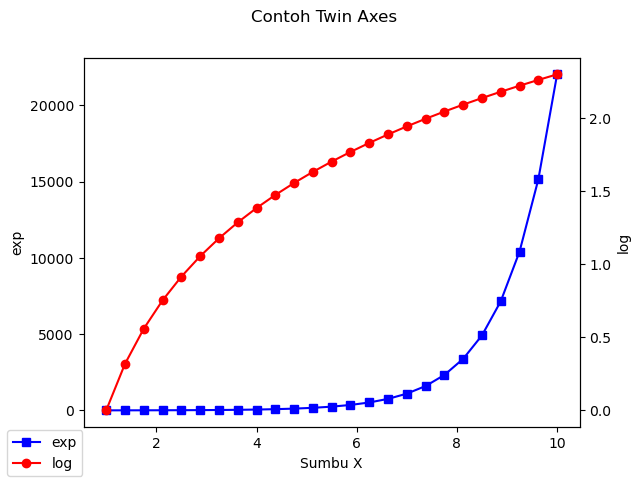

In [4]:
fig, ax1 = plt.subplots()

ax1.plot(x, np.exp(x), 'bs-', label='exp')
ax1.set_xlabel('Sumbu X')
ax1.set_ylabel('exp')

ax2 = ax1.twinx()
ax2.plot(x, np.log(x), 'ro-', label='log')
ax2.set_ylabel('log')

fig.suptitle('Contoh Twin Axes')
fig.legend(loc='lower left')

plt.show()

## Kasus Twin Axes 2

In [6]:
x = np.random.randint(16, 40, size=30)  # (low, high, size)
x

array([32, 37, 26, 36, 24, 17, 32, 17, 35, 37, 26, 29, 24, 34, 27, 23, 30,
       30, 35, 29, 22, 36, 29, 29, 30, 30, 35, 18, 31, 23])

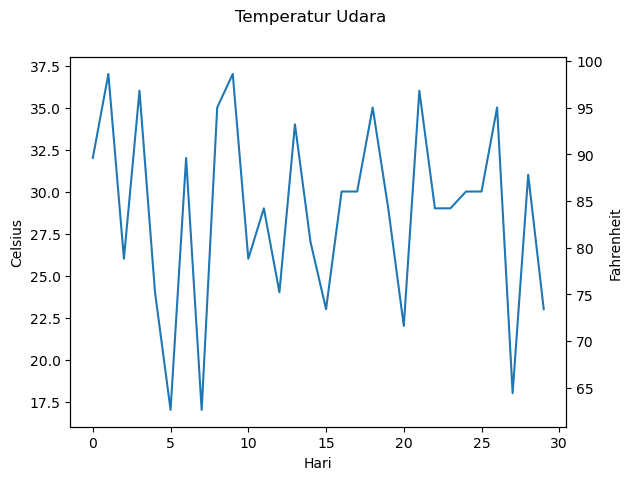

In [7]:
# fungsi Celsius → Fahrenheit
def C2F(celsius=0):
    return (celsius * 1.8) + 32  

# fungsi Mengubah batas sumbu Y Celsius menjadi batas sumbu Y Fahrenheit.
def konversi_sumbu(ax1): 
    y1, y2 = ax1.get_ylim()         # mengambil batas bawah dan batas atas sumbu Y ax1.
    ax2.set_ylim(C2F(y1), C2F(y2))  # mengkonversikan ke farenheit, lalu jadikan batas sumbu Y ax2
    ax2.figure.canvas.draw()        # menggambar ulang (redraw) figure setelah batas sumbu Y ax2 diubah.

fig, ax1 = plt.subplots() 
ax2 = ax1.twinx()                   # Buat sumbu Y kedua yang berbagi sumbu X yang sama.

ax1.callbacks.connect('ylim_changed', konversi_sumbu) 
ax1.plot(x)                         # Kalau batas sumbu Y ax1 berubah, jalankan fungsi konversi_sumbu.
# ax1 Y-limit berubah
#         ↓
# event 'ylim_changed'
#         ↓
# konversi_sumbu(ax1)
#         ↓
# ambil batas Celsius
#         ↓
# konversi ke Fahrenheit
#         ↓
# ubah batas ax2

ax1.set_xlabel('Hari')
ax1.set_ylabel('Celsius') 
ax2.set_ylabel('Fahrenheit') 

fig.suptitle('Temperatur Udara') 
plt.show() 

